In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sandbox_df = pd.read_csv('../data/processed/august_2024_uk_sandbox.csv')

In [3]:
sandbox_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url
0,1eh2jmf,1.722471e+09,unitedkingdom,One part of tipping culture we should keep,[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...
1,1eh2nw8,1.722471e+09,unitedkingdom,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...
2,1eh2paw,1.722471e+09,uknews,"""boy"" of 17.","This is a man, not a boy. Throw the book at hi...",1,8,https://www.reddit.com/r/uknews/comments/1eh2p...
3,1eh2psa,1.722471e+09,policeuk,Drone Image of Southport Riot - New Public Ord...,NaN,243,88,https://i.redd.it/67dqlotc2yfd1.jpeg
4,1eh2u4b,1.722471e+09,ukpolitics,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/ukpolitics/comments/1...


Initial integrity check

- 10,249 posts for one month
- num_comments and score are int - good
- 6048 missing values in selftext - the column that contains the contents of the post. Bad - 59%

In [4]:
# check num rows/cols
sandbox_df.shape

(10249, 8)

In [5]:
# check data types of cols
sandbox_df.dtypes

id                  str
created_utc     float64
subreddit           str
title               str
selftext            str
score             int64
num_comments      int64
url                 str
dtype: object

In [6]:
# null values check
null_vals = sandbox_df.isnull().sum()
null_vals

id                 0
created_utc        0
subreddit          0
title              0
selftext        6048
score              0
num_comments       0
url              156
dtype: int64

In [7]:
# proportion null
null_vals/sandbox_df.shape[0]

id              0.000000
created_utc     0.000000
subreddit       0.000000
title           0.000000
selftext        0.590106
score           0.000000
num_comments    0.000000
url             0.015221
dtype: float64

Class balances

In [8]:
# check subreddit counts
subr_counts = sandbox_df['subreddit'].value_counts()
subr_counts

subreddit
unitedkingdom    5625
ukpolitics       2074
policeuk          832
LabourUK          680
uknews            627
reformuk          277
tories             75
brexit             57
gbnews              2
Name: count, dtype: int64

In [9]:
# check for subreddit imbalances
subr_counts/sandbox_df.shape[0]

subreddit
unitedkingdom    0.548834
ukpolitics       0.202361
policeuk         0.081179
LabourUK         0.066348
uknews           0.061177
reformuk         0.027027
tories           0.007318
brexit           0.005562
gbnews           0.000195
Name: count, dtype: float64

Stats for virality

In [10]:
# descriptive stats
virality_cols_df = sandbox_df.loc[:, ['num_comments', 'score']]

virality_cols_df.describe()

,num_comments,score
count,10249.000000,10249.000000
mean,42.542492,51.729730
std,136.178918,185.324393
min,0.000000,0.000000
25%,0.000000,1.000000
50%,1.000000,1.000000
75%,20.000000,18.000000
max,3065.000000,6159.000000


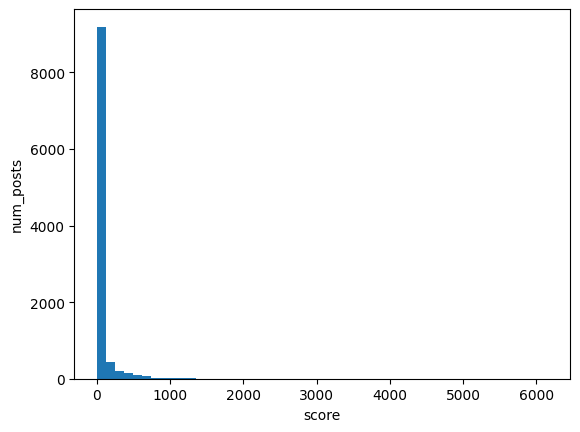

In [11]:
# Look at distribution of scores
plt.hist(virality_cols_df.loc[:, 'score'], bins=50)
plt.xlabel('score')
plt.ylabel('num_posts')
plt.show()

Vast majority of reddit posts have a score of <100. Big positive skew. Likely to need log transformed score for models

NB - score = num up votes - num down votes

In [12]:
# View top 10 highest scoring posts of the month 

sorted_by_score = sandbox_df.sort_values(by=['score'], ascending=False)
sorted_by_score.iloc[:10, :]

,id,created_utc,subreddit,title,selftext,score,num_comments,url
1860,1eku5df,1.722880e+09,uknews,Sky News journalist forced off air by muslim p...,NaN,6159,140,https://v.redd.it/l6u1z68quvgd1
3030,1en0txs,1.723106e+09,uknews,England gets tired of fascists having a tantru...,Is this the end of the riots?,4576,1213,https://www.nbcnews.com/news/world/london-high...
2630,1em8rtq,1.723028e+09,uknews,Nigel Farage Has Admitted Spreading Misinforma...,Surely this should be against ministerial rules?,4093,522,https://www.huffingtonpost.co.uk/entry/nigel-f...
6331,1ev5nc1,1.723975e+09,uknews,Misogyny to be treated as extremism by UK gove...,NaN,4077,1336,https://www.bbc.co.uk/news/articles/c15gn0lq7p5o
6899,1ewqwk5,1.724145e+09,unitedkingdom,What happened to this subreddit?,Two years ago this sub was memed on for how le...,3360,1916,https://www.reddit.com/r/unitedkingdom/comment...
5180,1erwapy,1.723624e+09,uknews,Liz Truss storms off stage after humiliating l...,[https://www.mirror.co.uk/news/politics/liz-tr...,3201,573,https://www.reddit.com/r/uknews/comments/1erwa...
148,1ehehto,1.722512e+09,uknews,Boy charged with Southport stabbing murders na...,NaN,2963,2082,https://www.liverpoolecho.co.uk/news/liverpool...
946,1ej5io2,1.722698e+09,uknews,Muslim stabbed at train station hours before f...,NaN,2870,1232,https://metro.co.uk/2024/08/02/muslim-stabbed-...
1556,1ekgv2y,1.722839e+09,uknews,Conservatives left UK wide open to far-right v...,NaN,2579,891,https://www.theguardian.com/uk-news/article/20...
2386,1elpvrr,1.722970e+09,uknews,Mindless UK riot thugs could be thrown in pris...,[https://www.mirror.co.uk/news/politics/uk-rio...,2183,775,https://www.reddit.com/r/uknews/comments/1elpv...


## Text length

Title/body word counts and length stats. Useful to know for BERT classifier - has mac token limit of 512

In [13]:
sandbox_df['title_length'] = sandbox_df.loc[:, 'title'].str.split().str.len()
sandbox_df['body_length'] = sandbox_df.loc[:, 'selftext'].str.split().str.len()
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,title_length,body_length
0,1eh2jmf,1.722471e+09,unitedkingdom,One part of tipping culture we should keep,[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...,8,1.0
1,1eh2nw8,1.722471e+09,unitedkingdom,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...,12,1.0
2,1eh2paw,1.722471e+09,uknews,"""boy"" of 17.","This is a man, not a boy. Throw the book at hi...",1,8,https://www.reddit.com/r/uknews/comments/1eh2p...,3,34.0
3,1eh2psa,1.722471e+09,policeuk,Drone Image of Southport Riot - New Public Ord...,NaN,243,88,https://i.redd.it/67dqlotc2yfd1.jpeg,11,NaN
4,1eh2u4b,1.722471e+09,ukpolitics,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/ukpolitics/comments/1...,12,1.0
...,...,...,...,...,...,...,...,...,...,...
10244,1f604rs,1.725146e+09,unitedkingdom,UC claim review,[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...,3,1.0
10245,1f609lh,1.725146e+09,policeuk,Concern for welfare...who's responsible?,This is a *frustrated at being sent round in c...,1,9,https://www.reddit.com/r/policeuk/comments/1f6...,4,558.0
10246,1f60uhs,1.725148e+09,unitedkingdom,:Accrington: Police tobacco sales fears over l...,NaN,1,16,https://www.lancashiretelegraph.co.uk/news/245...,10,NaN
10247,1f6166d,1.725149e+09,unitedkingdom,Please someone help im strugling here,[removed],1,1,https://www.reddit.com/r/unitedkingdom/comment...,6,1.0


In [14]:
sandbox_df.loc[:, ['title_length', 'body_length']].describe()

,title_length,body_length
count,10249.000000,4201.000000
mean,10.429213,32.740538
std,6.899601,106.924035
min,1.000000,0.000000
25%,6.000000,1.000000
50%,10.000000,1.000000
75%,13.000000,6.000000
max,65.000000,2165.000000


Merge title and body texts into single string. Anything with no selftext gets null replaced with an empty string. 

In [15]:
sandbox_df['selftext'] = sandbox_df['selftext'].str.replace(r'\[removed\]|\[deleted\]', '', regex=True)

In [ ]:
sandbox_df['combined_text'] = sandbox_df['title'].str.cat(sandbox_df['selftext'], sep='', na_rep='')
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,title_length,body_length,combined_text
0,1eh2jmf,1.722471e+09,unitedkingdom,One part of tipping culture we should keep,,1,0,https://www.reddit.com/r/unitedkingdom/comment...,8,1.0,One part of tipping culture we should keep
1,1eh2nw8,1.722471e+09,unitedkingdom,"Fast-Track to $10,000: The Easiest Ways to Ear...",,1,0,https://www.reddit.com/r/unitedkingdom/comment...,12,1.0,"Fast-Track to $10,000: The Easiest Ways to Ear..."
2,1eh2paw,1.722471e+09,uknews,"""boy"" of 17.","This is a man, not a boy. Throw the book at hi...",1,8,https://www.reddit.com/r/uknews/comments/1eh2p...,3,34.0,"""boy"" of 17.This is a man, not a boy. Throw th..."
3,1eh2psa,1.722471e+09,policeuk,Drone Image of Southport Riot - New Public Ord...,NaN,243,88,https://i.redd.it/67dqlotc2yfd1.jpeg,11,NaN,Drone Image of Southport Riot - New Public Ord...
4,1eh2u4b,1.722471e+09,ukpolitics,"Fast-Track to $10,000: The Easiest Ways to Ear...",,1,0,https://www.reddit.com/r/ukpolitics/comments/1...,12,1.0,"Fast-Track to $10,000: The Easiest Ways to Ear..."
...,...,...,...,...,...,...,...,...,...,...,...
10244,1f604rs,1.725146e+09,unitedkingdom,UC claim review,,1,0,https://www.reddit.com/r/unitedkingdom/comment...,3,1.0,UC claim review
10245,1f609lh,1.725146e+09,policeuk,Concern for welfare...who's responsible?,This is a *frustrated at being sent round in c...,1,9,https://www.reddit.com/r/policeuk/comments/1f6...,4,558.0,Concern for welfare...who's responsible?This i...
10246,1f60uhs,1.725148e+09,unitedkingdom,:Accrington: Police tobacco sales fears over l...,NaN,1,16,https://www.lancashiretelegraph.co.uk/news/245...,10,NaN,:Accrington: Police tobacco sales fears over l...
10247,1f6166d,1.725149e+09,unitedkingdom,Please someone help im strugling here,,1,1,https://www.reddit.com/r/unitedkingdom/comment...,6,1.0,Please someone help im strugling here


In [19]:
# check length of combined text
sandbox_df['combined_text_length'] = sandbox_df.loc[:, 'combined_text'].str.split().str.len()
sandbox_df['combined_text_length'].describe()

count    10249.000000
mean        23.464143
std         70.182246
min          1.000000
25%          7.000000
50%         11.000000
75%         15.000000
max       2191.000000
Name: combined_text_length, dtype: float64

If using words as tokens, the majority of posts will fall below the BERT token limit

## Domain Profiling

Extract the core base domains (e.g., bbc.co.uk, theguardian.com) from raw url column - useful for weak supervision labelling

Big mix of outlets (all of the main ones you'd expect to see)

In [17]:
core_domains = sandbox_df.loc[:, 'url'].str.split('//').str[1].str.split('/').str[0]

In [18]:
core_domains.value_counts()

url
www.reddit.com                                  3452
www.bbc.co.uk                                    773
i.redd.it                                        692
www.theguardian.com                              690
www.telegraph.co.uk                              282
                                                ... 
tptimes.org                                        1
ladyfreethinker.org                                1
ivycraftscottage.etsy.com                          1
jobs.southessex.ac.uk                              1
internationalnewsandstories4748.blogspot.com       1
Name: count, Length: 604, dtype: int64